In [1]:
# Verbindung zu Google Drive aufbauen
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


✅ ALKIS geladen | CRS: EPSG:25832
✅ 5 Szenen gefunden:
  - LC08_L2SP_194025_20250701_20250711_02_T1
  - LC08_L2SP_194025_20250818_20250821_02_T1
  - LC08_L2SP_194025_20250919_20250929_02_T1
  - LC09_L2SP_194025_20250810_20250811_02_T1
  - LC09_L2SP_194025_20250826_20250902_02_T1

🔄 LC08_L2SP_194025_20250701_20250711_02_T1
  ✔ Klare Pixel: 148,895 / 171,500 (86.8%)
  ✔ NDVI | Min: -0.023  Mean: 0.283  Max: 0.584
  ✔ Gespeichert: LC08_L2SP_194025_20250701_20250711_02_T1_NDVI.tif

🔄 LC08_L2SP_194025_20250818_20250821_02_T1
  ✔ Klare Pixel: 171,500 / 171,500 (100.0%)
  ✔ NDVI | Min: -0.058  Mean: 0.265  Max: 0.546
  ✔ Gespeichert: LC08_L2SP_194025_20250818_20250821_02_T1_NDVI.tif

🔄 LC08_L2SP_194025_20250919_20250929_02_T1
  ✔ Klare Pixel: 171,497 / 171,500 (100.0%)
  ✔ NDVI | Min: -0.080  Mean: 0.257  Max: 0.543
  ✔ Gespeichert: LC08_L2SP_194025_20250919_20250929_02_T1_NDVI.tif

🔄 LC09_L2SP_194025_20250810_20250811_02_T1
  ✔ Klare Pixel: 171,500 / 171,500 (100.0%)
  ✔ NDVI | Min: -0.054  

/tmp/ipykernel_881/2443026675.py:182: RuntimeWarning: Mean of empty slice
  ndvi_mean = np.nanmean(ndvi_stack, axis=0)


✔ NDVI_MEAN gespeichert
  Mean: 0.268
  Min:  -0.046
  Max:  0.519

Gebiet                       Mean     Min     Max     Std      n
  Rottenbauer-Nord          0.242    0.057    0.426  ±0.080     468
  Rottenbauer-Süd           0.234    0.085    0.408  ±0.067     481
  Lengfeld                  0.238    0.111    0.356  ±0.054     178
  Lengfeld-Kern             0.216    0.077    0.396  ±0.066     242
  Hubland Grünfläche        0.326    0.111    0.435  ±0.049     229
  Hubland Terrassen         0.189    0.069    0.336  ±0.070      59
  Hubland Quartier I        0.201    0.081    0.313  ±0.058      70
  Hubland Quartier II       0.162    0.029    0.334  ±0.073      32
  Hubland Quartier III      0.224    0.038    0.374  ±0.077     157
  ─────────────────────────────────────────────────────────────────
  Hubland-Gesamt            0.256    0.029    0.435  ±0.088     545
  Gartenstadt               0.262    0.120    0.442  ±0.068     481


/tmp/ipykernel_881/2443026675.py:256: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom       = gdf_reproj.geometry.unary_union
/tmp/ipykernel_881/2443026675.py:268: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid   = hub_reproj.geometry.unary_union.centroid


✅ Grafik gespeichert: NDVI_Auswertung.png


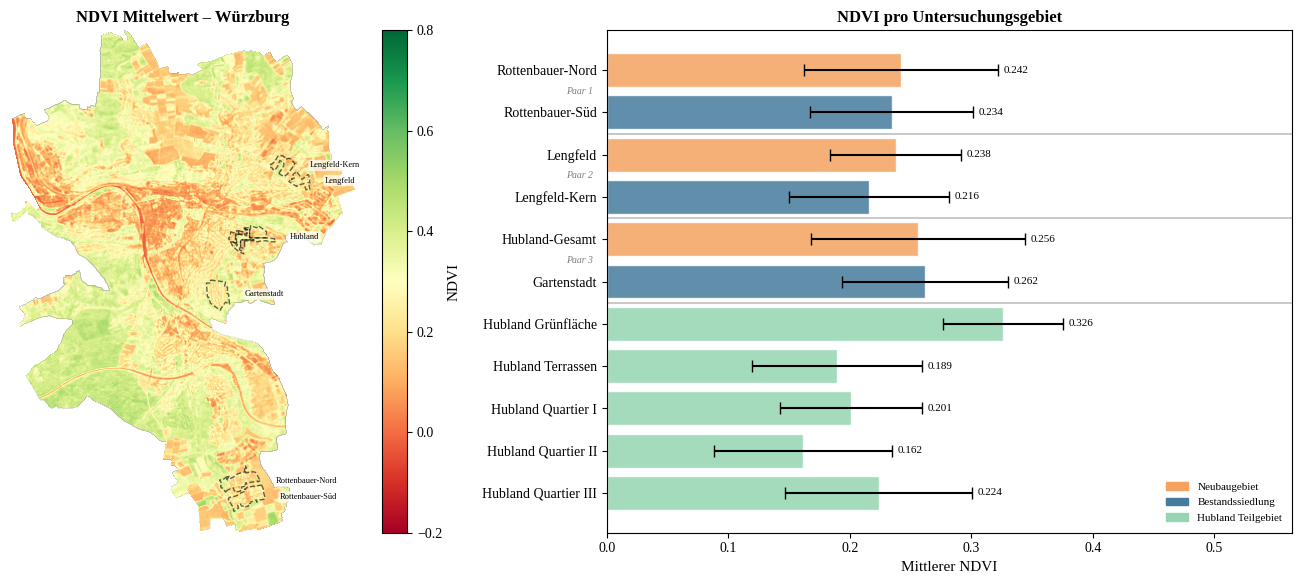

In [2]:

#  NOTEBOOK 2 – NDVI
#  Aufgabe: NDVI berechnen, Mittelwert bilden, Gebiete auswerten
#  Input:   Landsat/Clipped/ (B4, B5, CLEAR_MASK)
#  Output:  NDVI/Szenen/ + NDVI/NDVI_MEAN.tif + Grafiken/

import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import os
from rasterio.mask import mask as rio_mask
from rasterio.transform import rowcol

# SETUP

base       = "/content/drive/MyDrive/Colab_Notebooks"
clip_path  = f"{base}/Landsat/Clipped"
out_path   = f"{base}/NDVI"
szenen_path = f"{base}/NDVI/Szenen"
alkis_path = f"{base}/ALKIS/ALKIS_Stadt_Wue/ALKIS_Stadt_Wue.shp"

os.makedirs(szenen_path, exist_ok=True)
os.makedirs(f"{base}/Grafiken", exist_ok=True)

NODATA   = -9999.0
NDVI_MIN = -1.0
NDVI_MAX =  1.0

# ── Farben ────────────────────────────────────────────────────────────────────
FARBE_NEUBAU  = "#f4a261"
FARBE_BESTAND = "#457b9d"
FARBE_TEILGEB = "#95d5b2"

# ── APA 7 Plotstil ────────────────────────────────────────────────────────────
mpl.rcParams["font.family"]      = "serif"
mpl.rcParams["font.serif"]       = ["Liberation Serif", "DejaVu Serif", "Georgia"]
mpl.rcParams["font.size"]        = 12
mpl.rcParams["axes.titlesize"]   = 12
mpl.rcParams["axes.labelsize"]   = 11
mpl.rcParams["xtick.labelsize"]  = 10
mpl.rcParams["ytick.labelsize"]  = 10
mpl.rcParams["legend.fontsize"]  = 10
mpl.rcParams["axes.facecolor"]   = "white"
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.grid"]        = False
mpl.rcParams["savefig.dpi"]      = 300
mpl.rcParams["savefig.bbox"]     = "tight"
mpl.rcParams["legend.frameon"]   = False

# ── ALKIS laden ───────────────────────────────────────────────────────────────
alkis = gpd.read_file(alkis_path)
print(f"✅ ALKIS geladen | CRS: {alkis.crs}")

# ── Szenen-IDs aus Clipped-Ordner ableiten ────────────────────────────────────
scene_ids = sorted(set(
    f.replace("_CLEAR_MASK.tif", "")
    for f in os.listdir(clip_path)
    if f.endswith("_CLEAR_MASK.tif")
))
print(f"✅ {len(scene_ids)} Szenen gefunden:")
for s in scene_ids:
    print(f"  - {s}")

shapefile_pfade = {
    "Rottenbauer-Nord":     f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_Nord.shp",
    "Rottenbauer-Süd":      f"{base}/Shapefiles_Gebiete/Rottenbauer/Shape_Rottenbauer_alt.shp",
    "Lengfeld":             f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld.shp",
    "Lengfeld-Kern":        f"{base}/Shapefiles_Gebiete/Lengfeld/Shape_Lengfeld_alt.shp",
    "Hubland Grünfläche":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gruenflaeche.shp",
    "Hubland Terrassen":    f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hublandterrassen.shp",
    "Hubland Quartier I":   f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_I.shp",
    "Hubland Quartier II":  f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_II_plus_BBP_70.shp",
    "Hubland Quartier III": f"{base}/Shapefiles_Gebiete/Hubland/Shape_Quartier_III.shp",
    "Hubland-Gesamt":       f"{base}/Shapefiles_Gebiete/Hubland/Shape_Hubland_Gesamt.shp",
    "Gartenstadt":          f"{base}/Shapefiles_Gebiete/Gartenstadt/Shape_Gartenstadt.shp",
}

gebiete_gdfs = {name: gpd.read_file(pfad)
                for name, pfad in shapefile_pfade.items()}
gebiete_final  = gebiete_gdfs  # ← alle Gebiete inkl. Hubland-Gesamt bereits drin
hubland_gesamt = gebiete_gdfs["Hubland-Gesamt"]  # ← für Karte benötigt
# ═══════════════════════════════════════════════════════════════════════════════
# SCHRITT 1: NDVI pro Szene berechnen
# ═══════════════════════════════════════════════════════════════════════════════

ndvi_stack = []
meta_ref   = None

for scene_id in scene_ids:
    print(f"\n{'='*60}")
    print(f"🔄 {scene_id}")

    b4_path   = os.path.join(clip_path, f"{scene_id}_SR_B4_clip.tif")
    b5_path   = os.path.join(clip_path, f"{scene_id}_SR_B5_clip.tif")
    mask_path = os.path.join(clip_path, f"{scene_id}_CLEAR_MASK.tif")

    # Dateien prüfen
    fehlend = [p for p in [b4_path, b5_path, mask_path]
               if not os.path.exists(p)]
    if fehlend:
        print(f"  ⚠️ Fehlende Dateien: {fehlend} – Szene übersprungen!")
        continue

    # ── B4 & B5 laden ────────────────────────────────────────────────────────
    with rasterio.open(b4_path) as src:
        red  = src.read(1).astype(np.float32)
        meta = src.meta.copy()
        nd   = src.nodata
        if nd is not None:
            red[red == nd] = np.nan
        red[red == 0] = np.nan

    with rasterio.open(b5_path) as src:
        nir = src.read(1).astype(np.float32)
        nd  = src.nodata
        if nd is not None:
            nir[nir == nd] = np.nan
        nir[nir == 0] = np.nan

    # ── Wolkenmaske laden (bereits in Notebook 1 berechnet) ──────────────────
    with rasterio.open(mask_path) as src:
        clear_mask = src.read(1)

    pct = clear_mask.sum() / clear_mask.size * 100
    print(f"  ✔ Klare Pixel: {clear_mask.sum():,} / "
          f"{clear_mask.size:,} ({pct:.1f}%)")

    # ── Wolkenpixel ausschließen ──────────────────────────────────────────────
    red = np.where(clear_mask == 1, red, np.nan)
    nir = np.where(clear_mask == 1, nir, np.nan)

    # ── NDVI berechnen ────────────────────────────────────────────────────────
    # NDVI = (NIR - ROT) / (NIR + ROT)
    # errstate unterdrückt Division-durch-0 Warnungen
    with np.errstate(invalid="ignore", divide="ignore"):
        ndvi = np.where(
            (~np.isnan(red)) & (~np.isnan(nir)) & ((nir + red) != 0),
            (nir - red) / (nir + red),
            np.nan
        )

    # ── Plausibilitätsfilter [-1, 1] ─────────────────────────────────────────
    ndvi = np.where(
        (ndvi >= NDVI_MIN) & (ndvi <= NDVI_MAX),
        ndvi, np.nan
    )

    valid = ndvi[~np.isnan(ndvi)]
    if len(valid) == 0:
        print("  ⚠️ Keine gültigen Pixel – Szene übersprungen!")
        continue

    print(f"  ✔ NDVI | Min: {np.nanmin(valid):.3f}  "
          f"Mean: {np.nanmean(valid):.3f}  Max: {np.nanmax(valid):.3f}")

    # ── Pro Szene speichern ───────────────────────────────────────────────────
    out_meta = meta.copy()
    out_meta.update(dtype=rasterio.float32, count=1, nodata=NODATA)
    szene_out = os.path.join(szenen_path, f"{scene_id}_NDVI.tif")
    arr_out   = np.where(np.isnan(ndvi), NODATA, ndvi)

    with rasterio.open(szene_out, "w", **out_meta) as dst:
        dst.write(arr_out.astype(np.float32), 1)
    print(f"  ✔ Gespeichert: {scene_id}_NDVI.tif")

    ndvi_stack.append(ndvi)
    if meta_ref is None:
        meta_ref = out_meta.copy()

# ═══════════════════════════════════════════════════════════════════════════════
# SCHRITT 2: Pixelweiser Mittelwert über alle Szenen
# ═══════════════════════════════════════════════════════════════════════════════

ndvi_stack = np.array(ndvi_stack)
print(f"\nShape des NDVI-Stacks: {ndvi_stack.shape} "
      f"→ {ndvi_stack.shape[0]} Szenen")

# nanmean ignoriert NaN → Wolkenlücken werden durch andere Szenen gefüllt
ndvi_mean = np.nanmean(ndvi_stack, axis=0)

ndvi_mean_path = os.path.join(out_path, "NDVI_MEAN.tif")
arr_out = np.where(np.isnan(ndvi_mean), NODATA, ndvi_mean)
with rasterio.open(ndvi_mean_path, "w", **meta_ref) as dst:
    dst.write(arr_out.astype(np.float32), 1)
print(f"✔ NDVI_MEAN gespeichert")
print(f"  Mean: {np.nanmean(ndvi_mean):.3f}")
print(f"  Min:  {np.nanmin(ndvi_mean):.3f}")
print(f"  Max:  {np.nanmax(ndvi_mean):.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# SCHRITT 3: Gebietsauswertung
# ═══════════════════════════════════════════════════════════════════════════════

def ndvi_stats(gdf, raster_path, nodata=NODATA):
    """Schneidet NDVI_MEAN auf Gebiet zu und berechnet Statistiken."""
    with rasterio.open(raster_path) as src:
        gdf_reproj = gdf.to_crs(src.crs)
        geoms      = list(gdf_reproj.geometry)
        clipped, _ = rio_mask(src, geoms, crop=True, nodata=nodata)
    arr = clipped[0].astype(np.float32)
    arr[arr == nodata] = np.nan
    valid = arr[~np.isnan(arr)]
    if len(valid) == 0:
        return {"mean": np.nan, "min": np.nan,
                "max": np.nan, "std": np.nan, "n": 0}
    return {
        "mean": np.nanmean(valid),
        "min":  np.nanmin(valid),
        "max":  np.nanmax(valid),
        "std":  np.nanstd(valid),
        "n":    len(valid),
    }

print("\n" + "=" * 65)
print(f"{'Gebiet':<25} {'Mean':>7} {'Min':>7} {'Max':>7} "
      f"{'Std':>7} {'n':>6}")
print("=" * 65)

ergebnisse_ndvi = {}
for name, gdf in gebiete_final.items():
    s = ndvi_stats(gdf, ndvi_mean_path)
    ergebnisse_ndvi[name] = s
    trennlinie = "─" * 65 if name == "Hubland-Gesamt" else ""
    if trennlinie:
        print(f"  {trennlinie}")
    print(f"  {name:<23} {s['mean']:>7.3f}  {s['min']:>7.3f}  "
          f"{s['max']:>7.3f}  ±{s['std']:>5.3f}  {s['n']:>6}")

# ═══════════════════════════════════════════════════════════════════════════════
# SCHRITT 4: Visualisierung
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: NDVI Karte ────────────────────────────────────────────────────────
ax = axes[0]
arr_plot = np.where(ndvi_mean == NODATA, np.nan, ndvi_mean)
im = ax.imshow(arr_plot, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
plt.colorbar(im, ax=ax, label="NDVI", fraction=0.046, pad=0.04)
ax.set_title("NDVI Mittelwert – Würzburg", fontweight="bold")
ax.axis("off")

# Gebietsumrisse einzeichnen
with rasterio.open(ndvi_mean_path) as src:
    raster_transform = src.transform
    raster_crs       = src.crs

beschriftet = set()
for name, gdf in gebiete_final.items():
    if name == "Hubland-Gesamt":
        continue
    gdf_reproj = gdf.to_crs(raster_crs)
    geom       = gdf_reproj.geometry.unary_union
    if hasattr(geom, "exterior"):
        xs, ys = geom.exterior.coords.xy
    else:
        xs, ys = geom.convex_hull.exterior.coords.xy
    rows, cols = rowcol(raster_transform, xs, ys)
    ax.plot(cols, rows, color="black", linewidth=1.0,
            linestyle="--", alpha=0.6)
    anzeige_name = "Hubland" if "Hubland" in name else name
    if anzeige_name not in beschriftet:
        if "Hubland" in name:
            hub_reproj = hubland_gesamt.to_crs(raster_crs)
            centroid   = hub_reproj.geometry.unary_union.centroid
        else:
            centroid = geom.centroid
        cr, cc = rowcol(raster_transform, centroid.x, centroid.y)
        ax.annotate(
            anzeige_name,
            xy=(max(cols), cr), xytext=(max(cols) + 15, cr),
            fontsize=6, ha="left", va="center", color="black",
            annotation_clip=False,
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", alpha=0.7, ec="none")
        )
        beschriftet.add(anzeige_name)

# ── Plot 2: Balkendiagramm mit Matched Pairs ──────────────────────────────────
ax = axes[1]

reihenfolge = [
    "Rottenbauer-Nord", "Rottenbauer-Süd",
    "Lengfeld",         "Lengfeld-Kern",
    "Hubland-Gesamt",   "Gartenstadt",
    "Hubland Grünfläche", "Hubland Terrassen",
    "Hubland Quartier I", "Hubland Quartier II", "Hubland Quartier III",
]

farben_dict = {
    "Rottenbauer-Nord":     FARBE_NEUBAU,
    "Rottenbauer-Süd":      FARBE_BESTAND,
    "Lengfeld":             FARBE_NEUBAU,
    "Lengfeld-Kern":        FARBE_BESTAND,
    "Hubland-Gesamt":       FARBE_NEUBAU,
    "Gartenstadt":          FARBE_BESTAND,
    "Hubland Grünfläche":   FARBE_TEILGEB,
    "Hubland Terrassen":    FARBE_TEILGEB,
    "Hubland Quartier I":   FARBE_TEILGEB,
    "Hubland Quartier II":  FARBE_TEILGEB,
    "Hubland Quartier III": FARBE_TEILGEB,
}

means  = [ergebnisse_ndvi[n]["mean"] for n in reihenfolge]
stds   = [ergebnisse_ndvi[n]["std"]  for n in reihenfolge]
farben = [farben_dict[n]              for n in reihenfolge]

bars = ax.barh(reihenfolge, means, xerr=stds,
               color=farben, alpha=0.85,
               edgecolor="white", capsize=4)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=8)

# Trennlinien zwischen Paaren
for y in [1.5, 3.5, 5.5]:
    ax.axhline(y=y, color="gray", linewidth=1.2,
               linestyle="-", alpha=0.5)

# Paar-Beschriftung
for y_pos, label in {0.5: "Paar 1",
                     2.5: "Paar 2",
                     4.5: "Paar 3"}.items():
    ax.text(-0.02, y_pos, label,
            transform=ax.get_yaxis_transform(),
            ha="right", va="center",
            fontsize=7, color="gray", style="italic")

# Legende
ax.legend(handles=[
    mpatches.Patch(color=FARBE_NEUBAU,  label="Neubaugebiet"),
    mpatches.Patch(color=FARBE_BESTAND, label="Bestandssiedlung"),
    mpatches.Patch(color=FARBE_TEILGEB, label="Hubland Teilgebiet"),
], fontsize=8, loc="lower right")

ax.set_xlim(0, max(means) + max(stds) + 0.15)
ax.set_xlabel("Mittlerer NDVI")
ax.set_title("NDVI pro Untersuchungsgebiet", fontweight="bold")
ax.axvline(x=0, color="grey", linewidth=0.8, linestyle="--")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    f"{base}/Grafiken/NDVI_Auswertung.png",
    dpi=300, bbox_inches="tight", facecolor="white"
)
print("✅ Grafik gespeichert: NDVI_Auswertung.png")
plt.show()

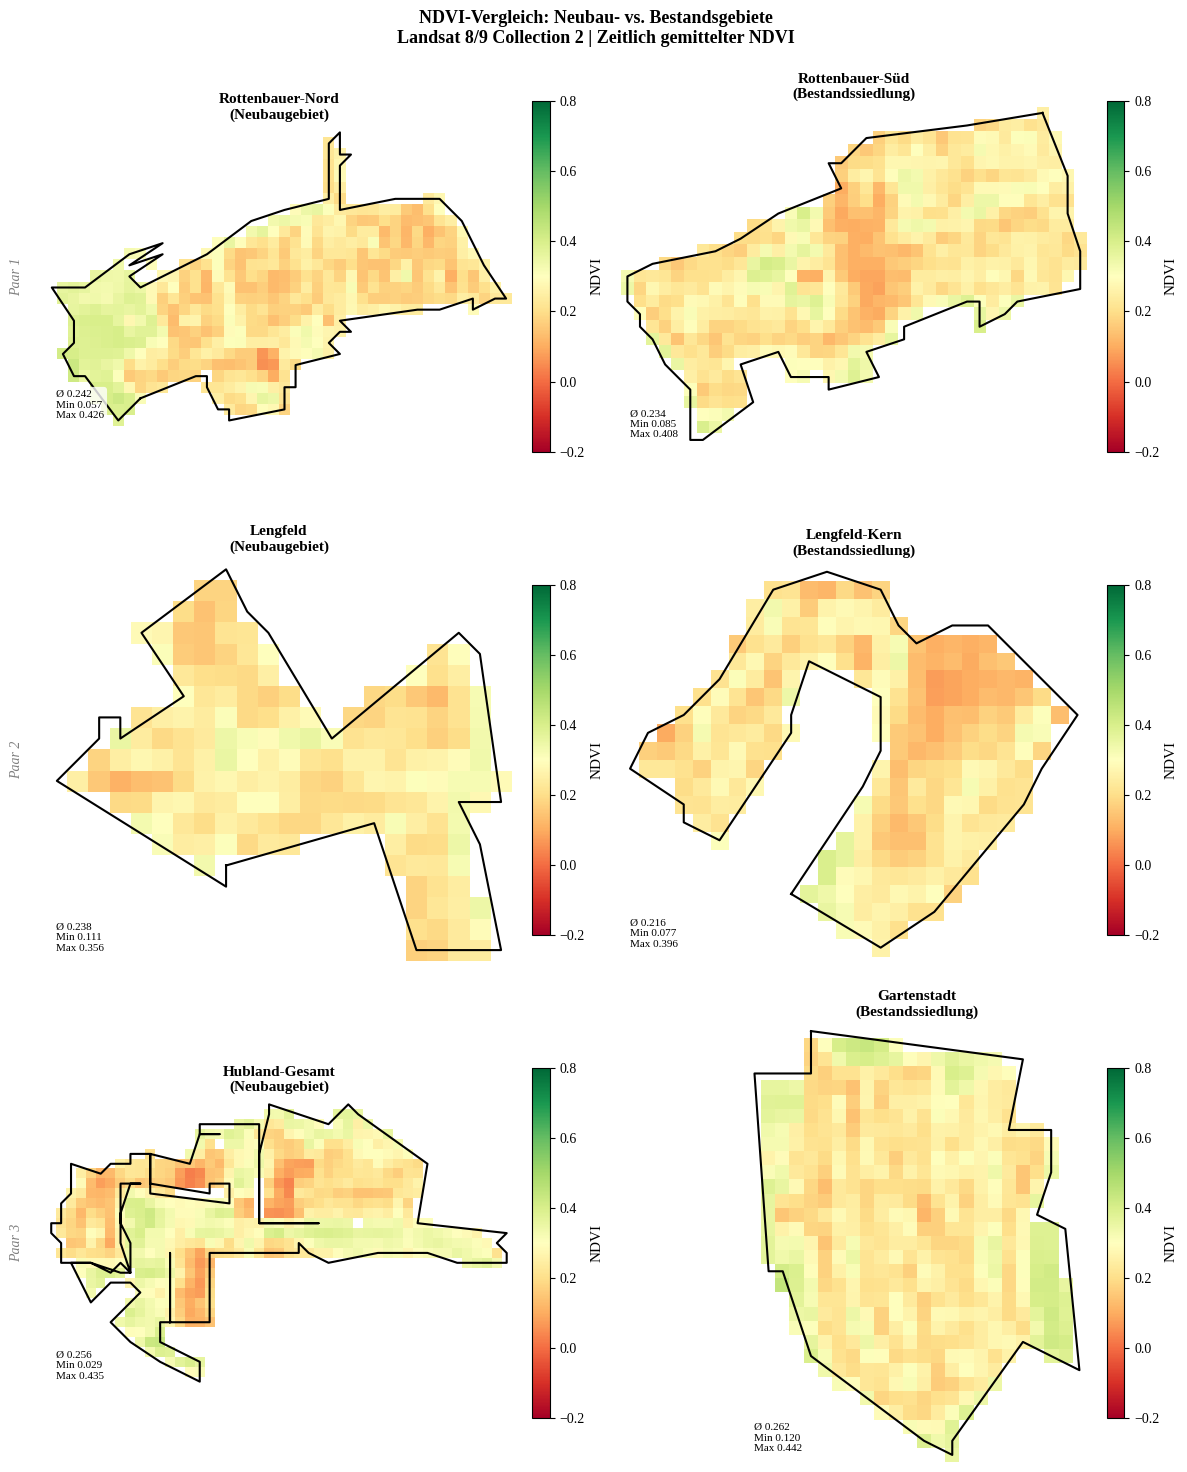

✅ Grafik gespeichert: NDVI_Paarvergleich_Karten.png


In [3]:
# ── Paarweise NDVI-Karten der Untersuchungsgebiete ────────────────────────────
from rasterio.mask import mask as rio_mask
import matplotlib.patches as mpatches

paare = [
    ("Rottenbauer-Nord", "Rottenbauer-Süd"),
    ("Lengfeld",         "Lengfeld-Kern"),
    ("Hubland-Gesamt",   "Gartenstadt"),
]

with rasterio.open(ndvi_mean_path) as src:
    raster_crs = src.crs

fig, axes = plt.subplots(len(paare), 2, figsize=(12, len(paare) * 5))

for row, (neubau, bestand) in enumerate(paare):
    for col, name in enumerate([neubau, bestand]):
        ax = axes[row, col]
        gdf = gebiete_final[name].to_crs(raster_crs)

        with rasterio.open(ndvi_mean_path) as src:
            clipped, clip_transform = rio_mask(
                src, list(gdf.geometry), crop=True, nodata=NODATA
            )
        arr = clipped[0].astype(np.float32)
        arr[arr == NODATA] = np.nan

        im = ax.imshow(arr, cmap="RdYlGn", vmin=-0.2, vmax=0.8)

        # Gebietsgrenze einzeichnen
        from rasterio.transform import rowcol as rc
        geom = gdf.geometry.union_all()
        if hasattr(geom, "exterior"):
            xs, ys = geom.exterior.coords.xy
        else:
            xs, ys = geom.convex_hull.exterior.coords.xy
        rows, cols = rc(clip_transform, xs, ys)
        ax.plot(cols, rows, color="black", linewidth=1.5)

        # Titel & Beschriftung
        gruppe = "Neubaugebiet" if col == 0 else "Bestandssiedlung"
        ax.set_title(f"{name}\n({gruppe})",
                     fontsize=11, fontweight="bold", color="black")
        ax.axis("off")

        # Colorbar
        plt.colorbar(im, ax=ax, label="NDVI",
                     fraction=0.046, pad=0.04, shrink=0.8)

        # Statistik als Textbox
        valid = arr[~np.isnan(arr)]
        if len(valid) > 0:
            stats_text = (f"Ø {np.nanmean(valid):.3f}\n"
                          f"Min {np.nanmin(valid):.3f}\n"
                          f"Max {np.nanmax(valid):.3f}")
            ax.text(0.02, 0.02, stats_text,
                    transform=ax.transAxes, fontsize=8,
                    va="bottom", ha="left",
                    bbox=dict(boxstyle="round,pad=0.3",
                              fc="white", alpha=0.8, ec="none"))

    # Paar-Label links
    axes[row, 0].text(-0.05, 0.5, f"Paar {row + 1}",
                      transform=axes[row, 0].transAxes,
                      fontsize=10, color="gray", style="italic",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "NDVI-Vergleich: Neubau- vs. Bestandsgebiete\n"
    "Landsat 8/9 Collection 2 | Zeitlich gemittelter NDVI",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{base}/Grafiken/NDVI_Paarvergleich_Karten.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Grafik gespeichert: NDVI_Paarvergleich_Karten.png")